<a href="https://colab.research.google.com/github/rag-hav-g/Black_Friday_sales_Analysis/blob/main/Black_Friday_sale_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/sample_data/BlackFriday.csv.crdownload')

In [ ]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,166986


In [ ]:
del df['Product_Category_2']
del df['Product_Category_3']

In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Purchase,0


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Purchase,0


In [ ]:
df['User_ID'].nunique()

5891

In [ ]:
df['User_ID'].unique()

array([1000001, 1000002, 1000003, ..., 1004113, 1005391, 1001529])

In [ ]:
df['Product_ID'].nunique()

3623

In [ ]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [ ]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [ ]:
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [ ]:
df['City_Category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [ ]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [ ]:
df['Marital_Status'].unique()

array([0, 1])

In [ ]:
df['Product_Category_1'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9])

In [ ]:
df['Purchase'].sum()/len(df['Purchase'])

np.float64(9333.859852635065)

In [ ]:
for col in df.columns:
  print(col)

User_ID
Product_ID
Gender
Age
Occupation
City_Category
Stay_In_Current_City_Years
Marital_Status
Product_Category_1
Purchase


In [ ]:
for col in df.columns:
  print(col,df[col].nunique())

User_ID 5891
Product_ID 3623
Gender 2
Age 7
Occupation 21
City_Category 3
Stay_In_Current_City_Years 5
Marital_Status 2
Product_Category_1 18
Purchase 17959


In [ ]:
df[df['Gender']=='M']

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


In [ ]:
len(df[df['Gender']=='M']),len(df[df['Gender']=='F'])

(405380, 132197)

In [ ]:
data = pd.DataFrame({'Ratio' : [len(df[df['Gender']=='M']),len(df[df['Gender']=='F'])]},index=['Mail','Female'])
data

,Ratio
Mail,405380
Female,132197


<Axes: ylabel='Ratio'>

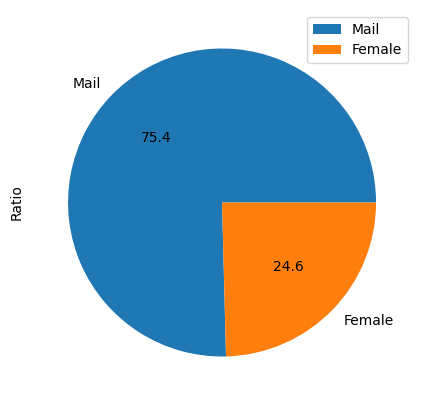

In [ ]:
data.plot.pie(y='Ratio',figsize=(5,5),autopct='%.1f')

In [ ]:
df.groupby('Gender').size()

,0
Gender,
F,132197
M,405380


<Axes: title={'center': 'Gender Ratio'}>

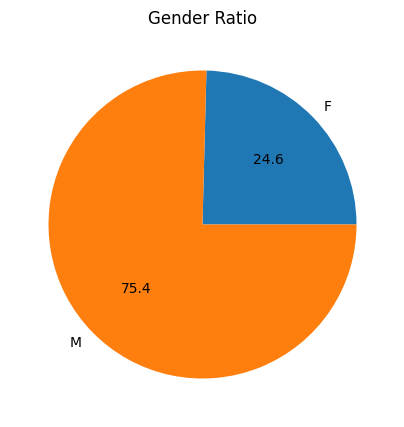

In [ ]:
df.groupby('Gender').size().plot(kind='pie',autopct='%.1f',figsize=(5,5),title='Gender Ratio')

<Axes: xlabel='Gender'>

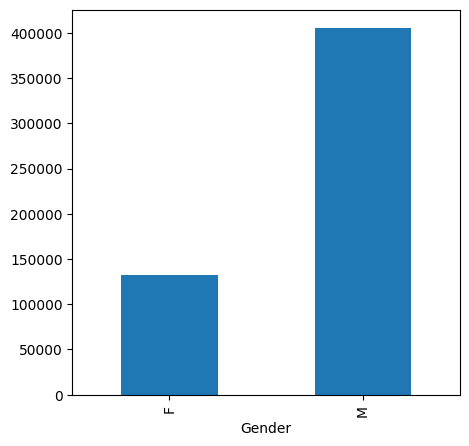

In [ ]:
df.groupby('Gender').size().plot(kind='bar',figsize=(5,5))

In [ ]:
df.groupby('Gender').sum()['Purchase']

,Purchase
Gender,
F,1164624021
M,3853044357


<Axes: ylabel='Purchase'>

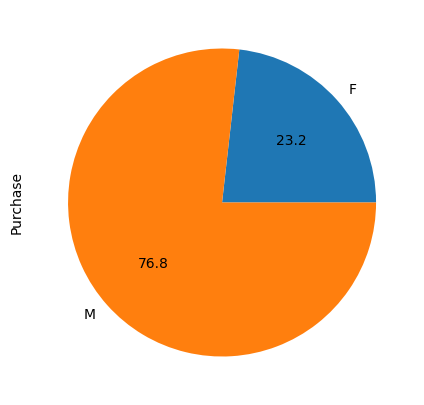

In [ ]:
df.groupby('Gender').sum()['Purchase'].plot(kind='pie',autopct='%.1f',figsize=(5,5))

<Axes: title={'center': 'Purchase Distribution By Age'}, xlabel='Age'>

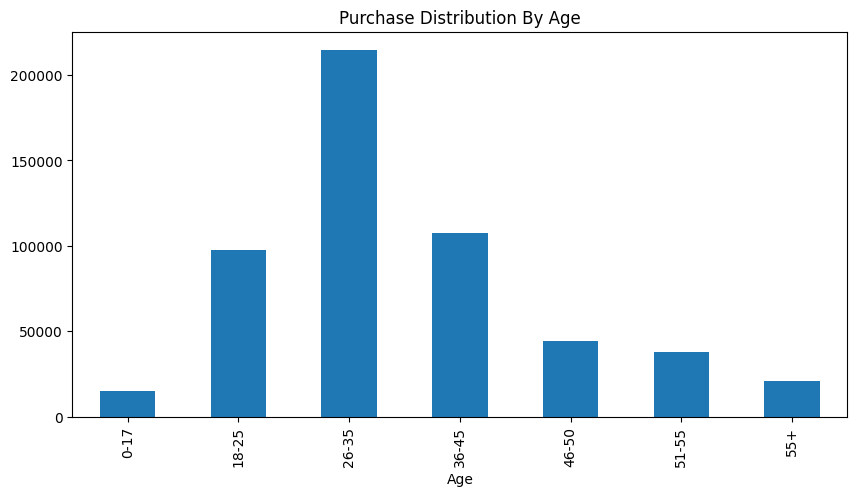

In [ ]:
df.groupby('Age').size().plot(kind='bar',figsize=(10,5),title="Purchase Distribution By Age")

In [ ]:
li=[]
for i in df['Age'].unique():
  li.append([i,df[df['Age']==i]['Product_ID'].nunique()])
li

[['0-17', 2300],
 ['55+', 2573],
 ['26-35', 3419],
 ['46-50', 3099],
 ['51-55', 2877],
 ['36-45', 3318],
 ['18-25', 3213]]

In [ ]:
df[df['Age']==i]['Product_ID'].nunique()

3213

In [ ]:
data=pd.DataFrame(li,columns=['Age','Products'])
data

,Age,Products
0,0-17,2300
1,55+,2573
2,26-35,3419
3,46-50,3099
4,51-55,2877
5,36-45,3318
6,18-25,3213


<Axes: title={'center': 'Product Distribution By Age'}, xlabel='Age'>

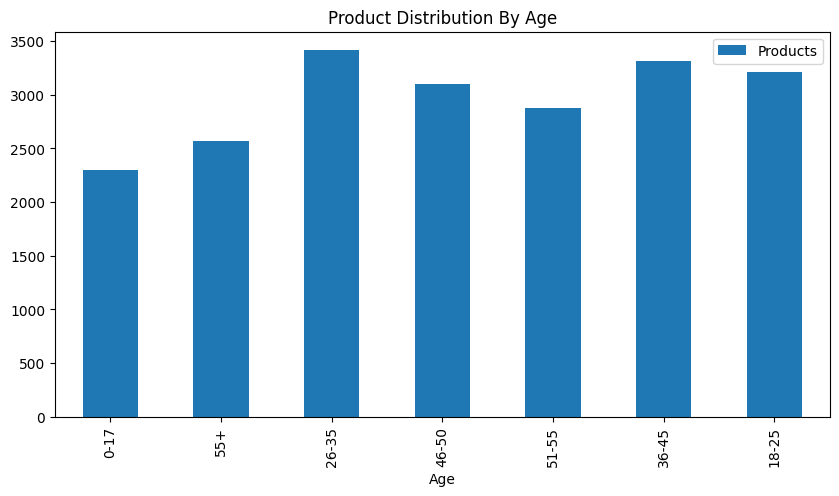

In [ ]:
data.plot(kind='bar',x='Age',y='Products',figsize=(10,5),title='Product Distribution By Age')

<Axes: title={'center': 'Purchase Distribution By Age'}, xlabel='Age'>

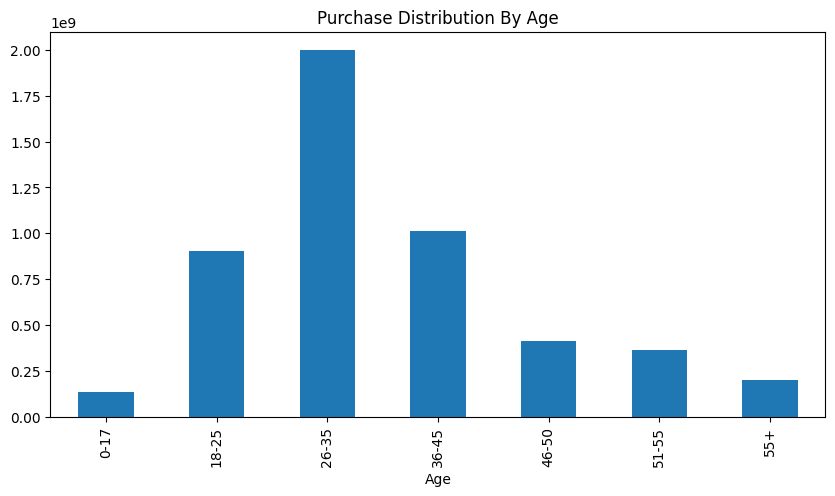

In [ ]:
df.groupby('Age').sum()['Purchase'].plot(kind='bar',figsize=(10,5),title='Purchase Distribution By Age')

<Axes: title={'center': 'Average purchase by age'}, xlabel='Age'>

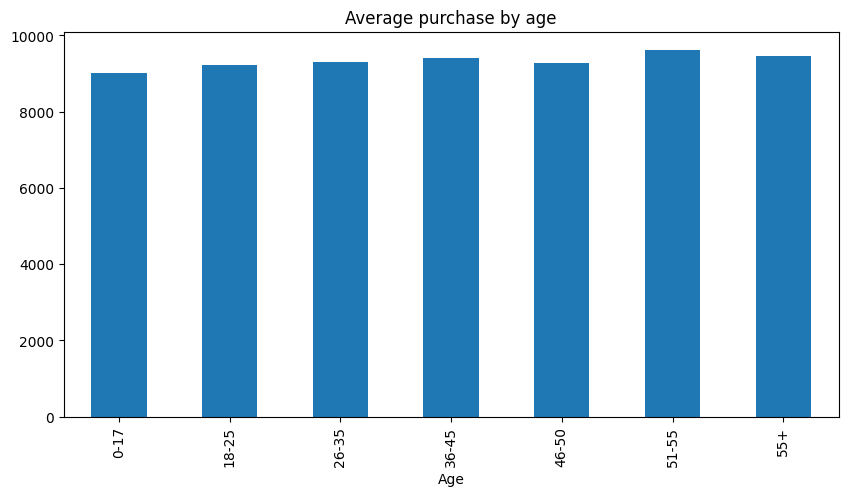

In [ ]:
df.groupby('Age')['Purchase'].mean().plot(kind='bar',figsize=(10,5),title='Average purchase by age')

<Axes: title={'center': 'Average purchase by age'}, ylabel='Purchase'>

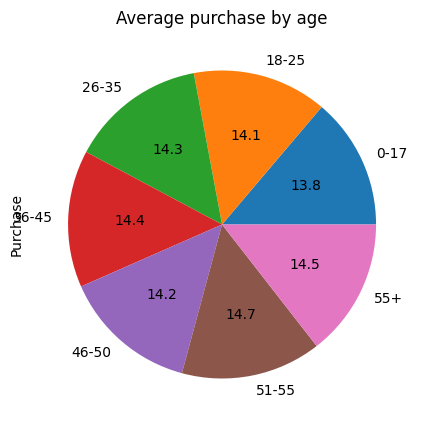

In [ ]:
df.groupby('Age')['Purchase'].mean().plot(kind='pie', autopct='%.1f',figsize=(10,5),title='Average purchase by age')

<Axes: title={'center': 'Purchase by Marital Status'}>

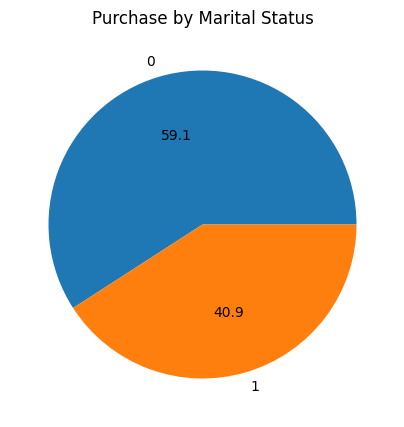

In [ ]:
df.groupby('Marital_Status').size().plot(kind='pie',autopct='%.1f',figsize=(5,5),title='Purchase by Marital Status')

<Axes: title={'center': 'Gender Ratio'}>

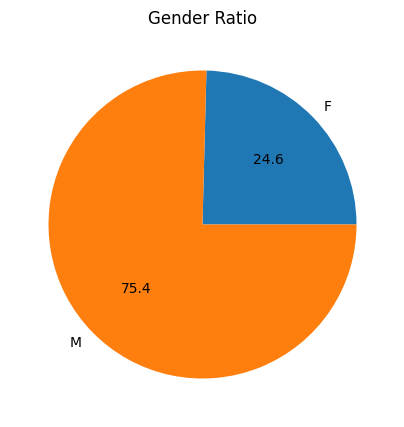

In [ ]:
df.groupby('Gender').size().plot(kind='pie',autopct='%.1f',figsize=(5,5),title='Gender Ratio')

<Axes: xlabel='Age', ylabel='count'>

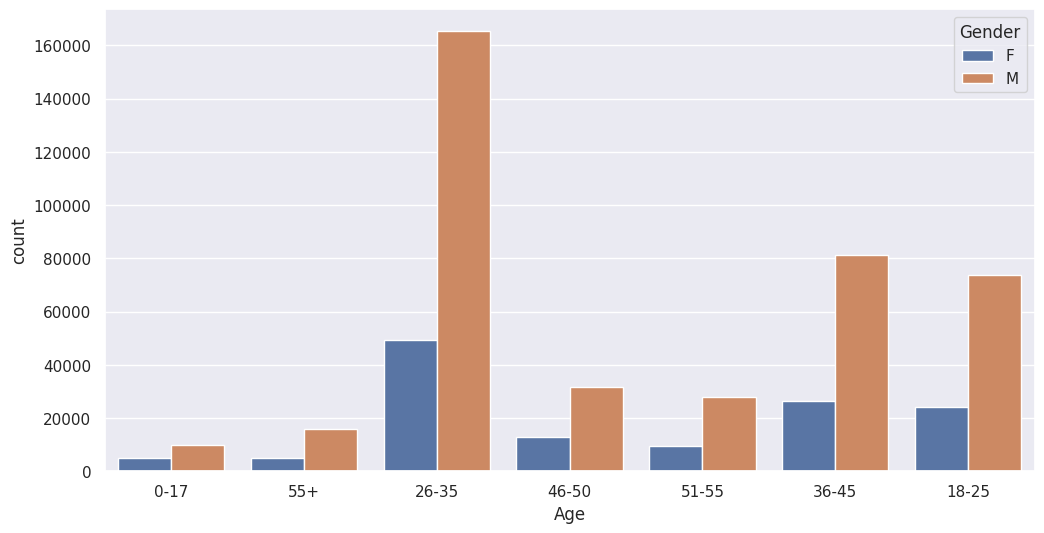

In [ ]:
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='Age',hue='Gender',data=df)

<Axes: xlabel='Gender', ylabel='count'>

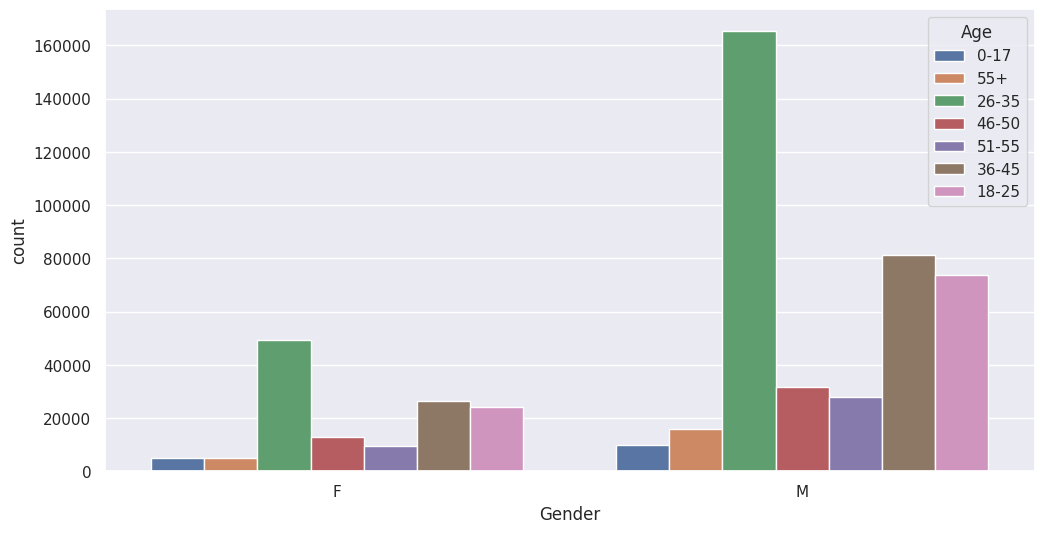

In [ ]:
 sns.countplot(x='Gender',hue='Age',data=df)

<Axes: xlabel='Gender', ylabel='count'>

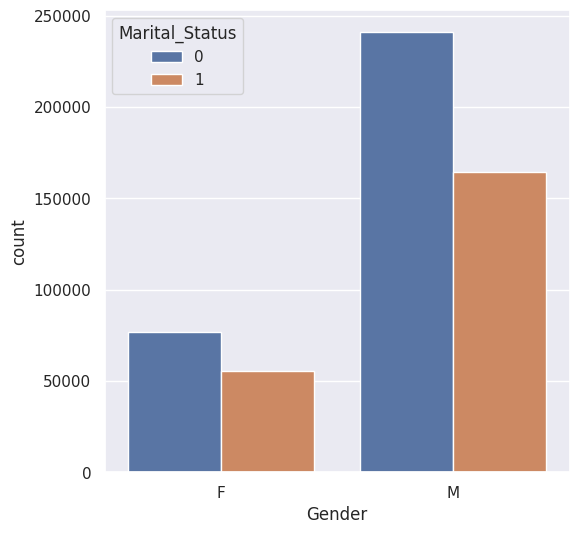

In [ ]:
 sns.set(rc={'figure.figsize':(6,6)})
 sns.countplot(x='Gender',hue='Marital_Status',data=df)

<Axes: xlabel='Marital_Status', ylabel='count'>

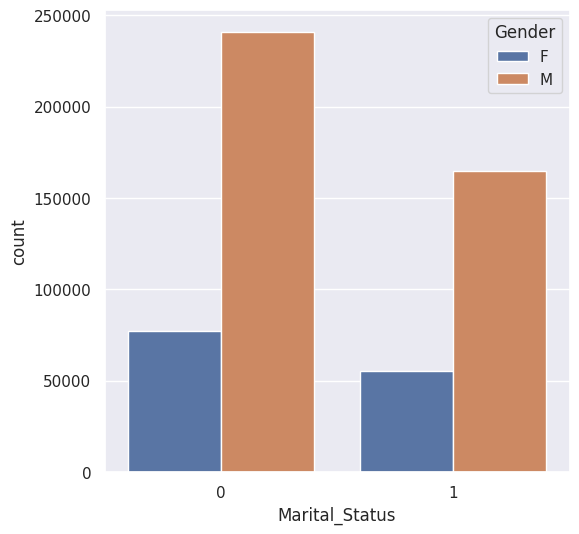

In [ ]:
 sns.set(rc={'figure.figsize':(6,6)})
 sns.countplot(x='Marital_Status',hue='Gender',data=df)

<Axes: xlabel='City_Category', ylabel='count'>

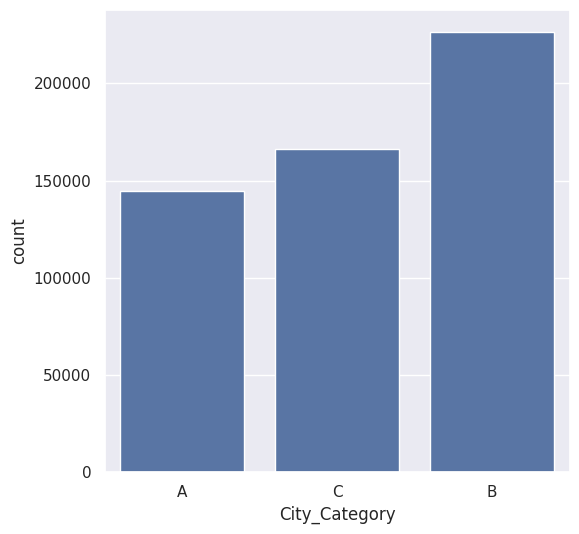

In [ ]:
sns.countplot(x=df['City_Category'])

<Axes: >

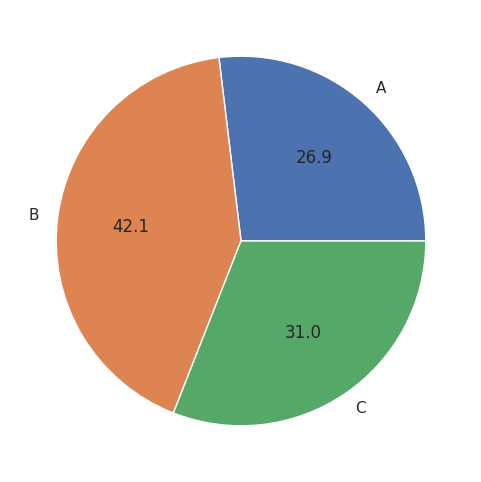

In [ ]:
df.groupby('City_Category').size().plot(kind='pie',autopct='%.1f',figsize=(6,6))

<Axes: xlabel='City_Category', ylabel='count'>

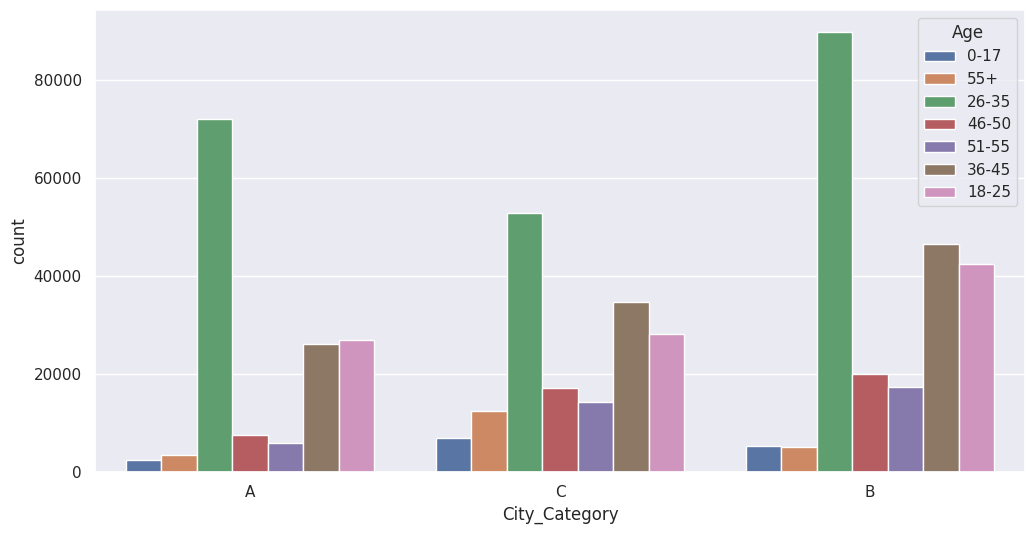

In [ ]:
 sns.set(rc={'figure.figsize':(12,6)})
 sns.countplot(x='City_Category',hue='Age',data=df)

<Axes: xlabel='City_Category', ylabel='count'>

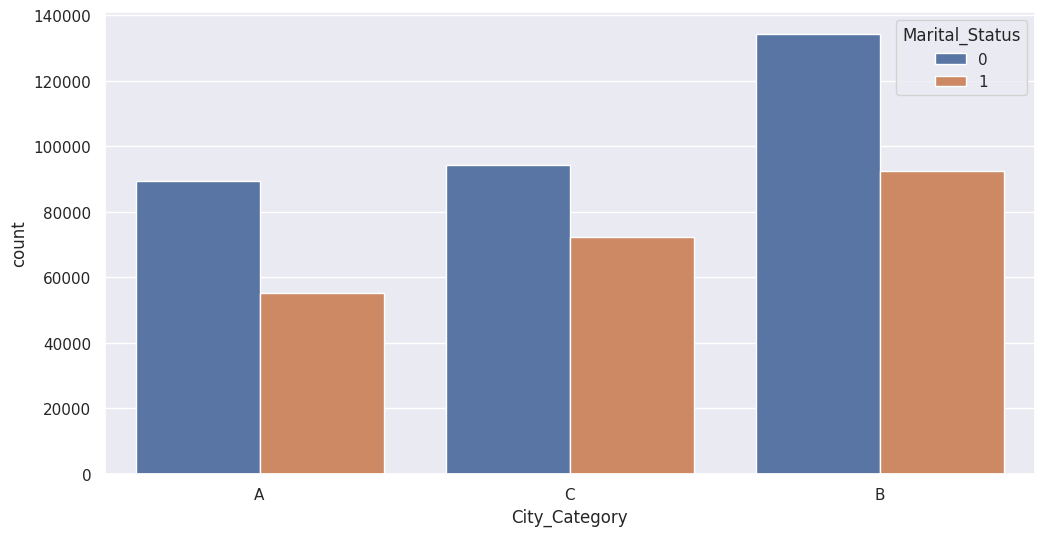

In [ ]:
sns.countplot(x='City_Category',hue='Marital_Status',data=df)

<Axes: xlabel='City_Category', ylabel='count'>

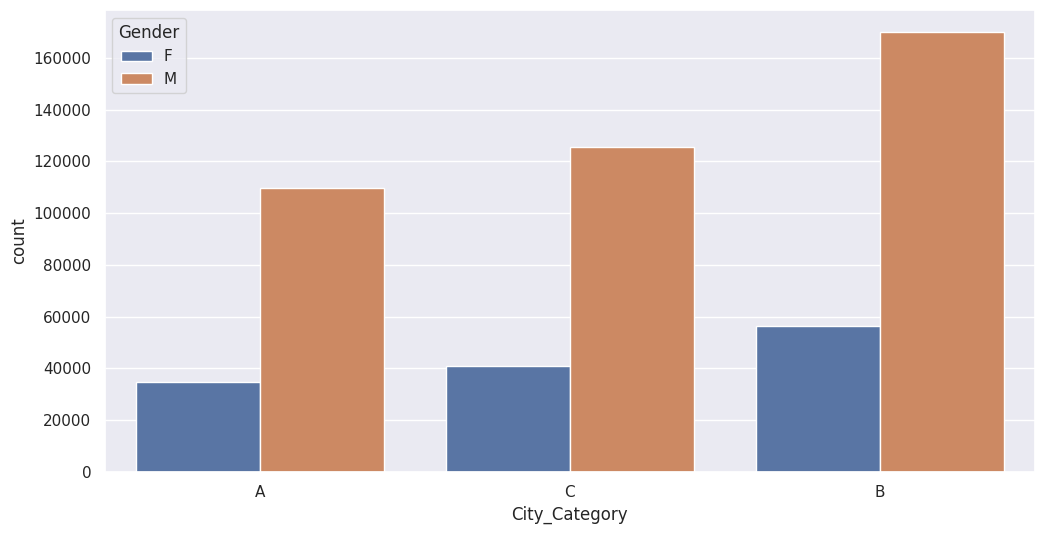

In [ ]:
sns.countplot(x='City_Category',hue='Gender',data=df)

<Axes: >

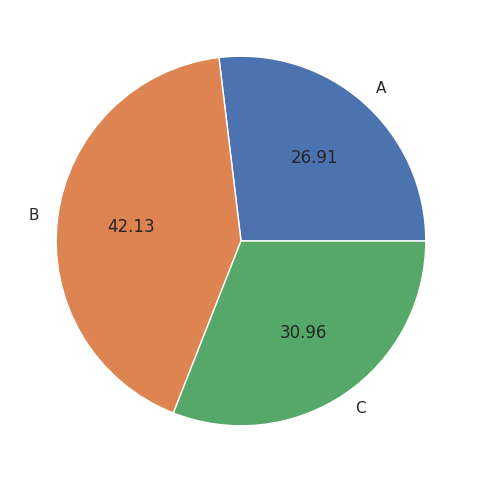

In [ ]:
df.groupby('City_Category').size().plot(kind='pie',autopct='%.2f',figsize=(6,6))

<Axes: ylabel='Purchase'>

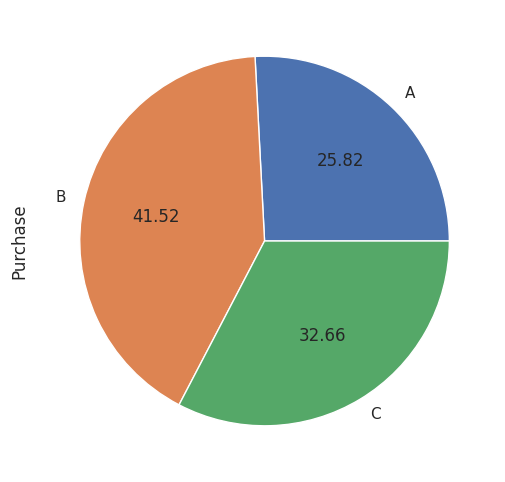

In [ ]:
df.groupby('City_Category')['Purchase'].sum().plot(kind='pie',autopct='%.2f',figsize=(6,6))

<Axes: ylabel='Purchase'>

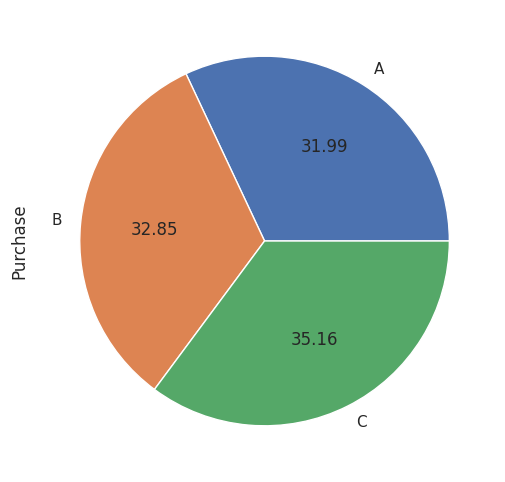

In [ ]:
df.groupby('City_Category')['Purchase'].mean().plot(kind='pie',autopct='%.2f',figsize=(6,6))

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

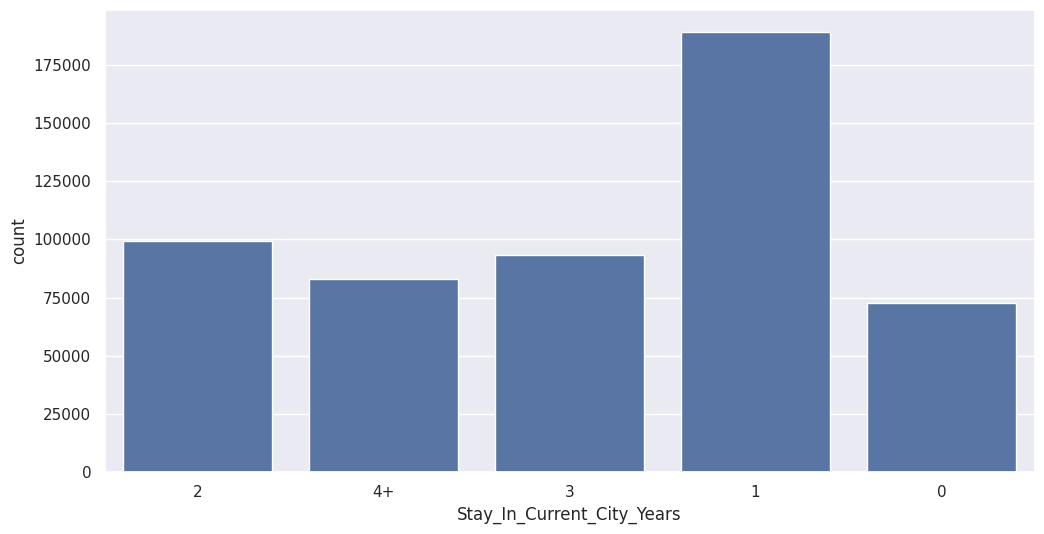

In [ ]:
sns.countplot(x=df['Stay_In_Current_City_Years'])

<Axes: >

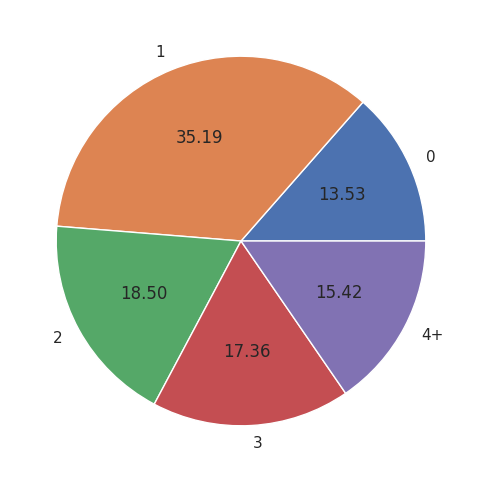

In [ ]:
df.groupby('Stay_In_Current_City_Years').size().plot(kind='pie',autopct='%.2f',figsize=(6,6))

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

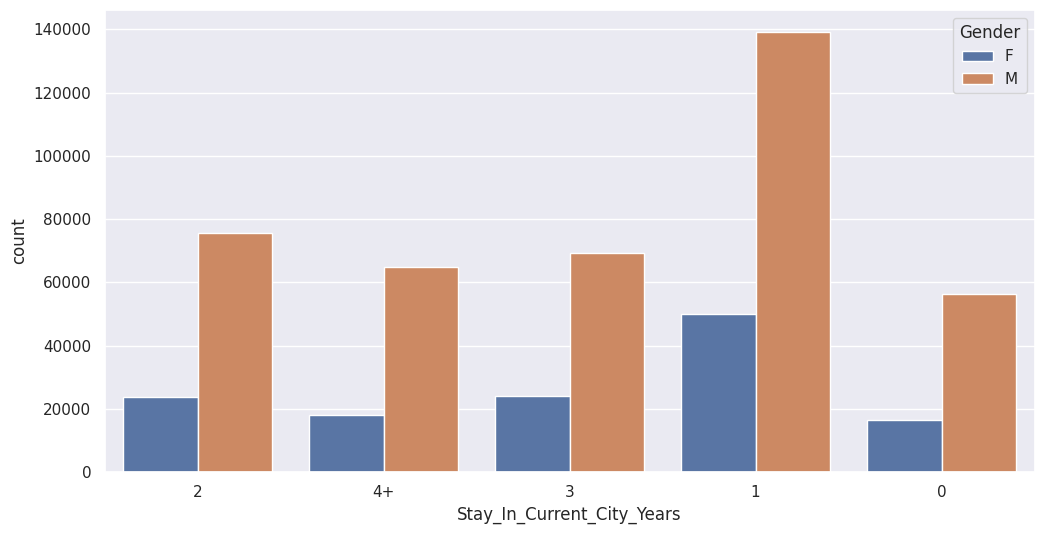

In [ ]:
sns.countplot(x='Stay_In_Current_City_Years',hue='Gender',data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

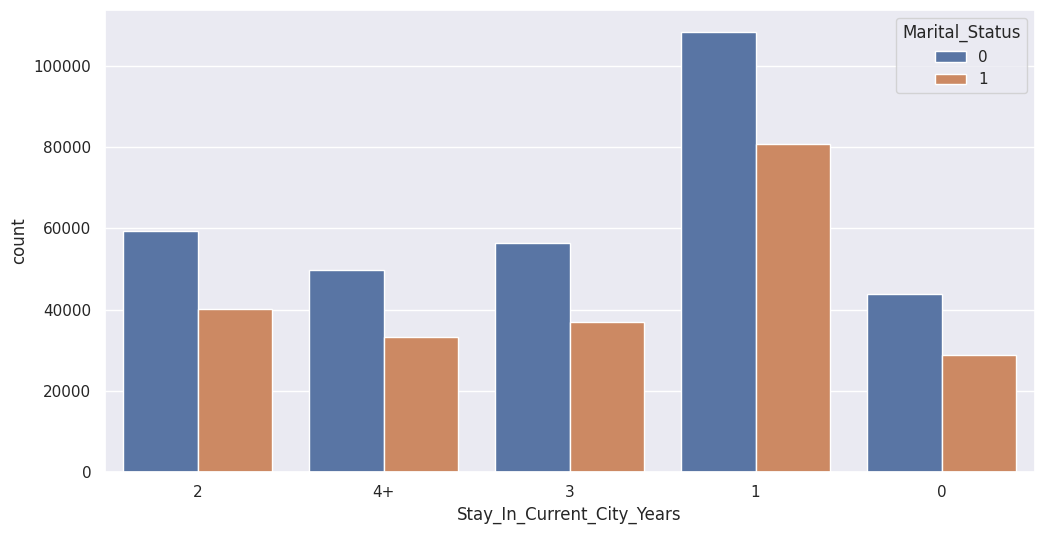

In [ ]:
sns.countplot(x='Stay_In_Current_City_Years',hue='Marital_Status',data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

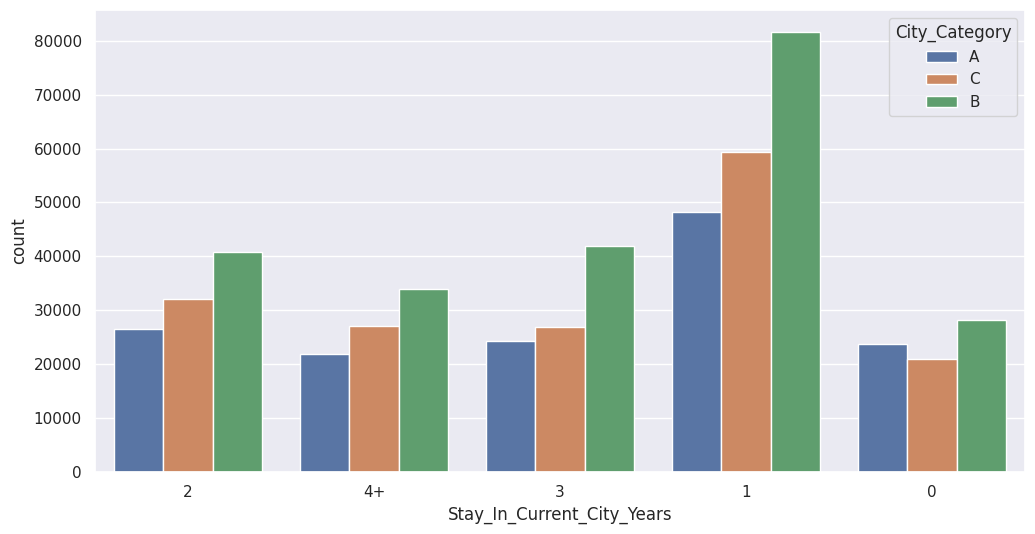

In [ ]:
sns.countplot(x='Stay_In_Current_City_Years',hue='City_Category',data=df)

<Axes: xlabel='City_Category', ylabel='count'>

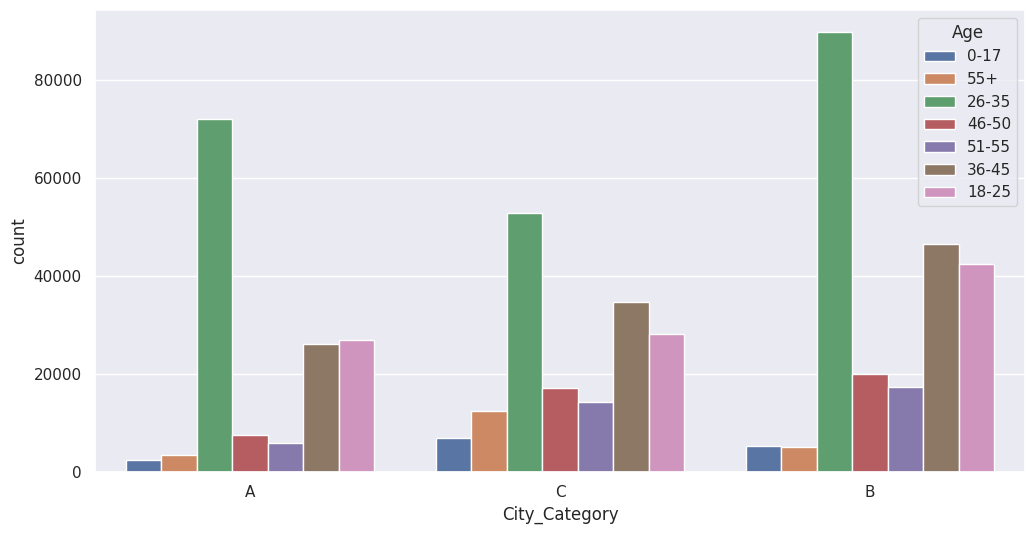

In [ ]:
sns.countplot(x='City_Category',hue='Age',data=df)

<Axes: xlabel='Stay_In_Current_City_Years'>

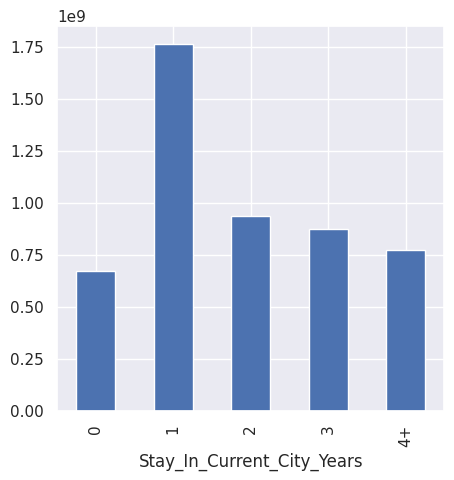

In [ ]:
df.groupby('Stay_In_Current_City_Years')['Purchase'].sum().plot(kind='bar',figsize=(5,5))

<Axes: xlabel='Occupation', ylabel='count'>

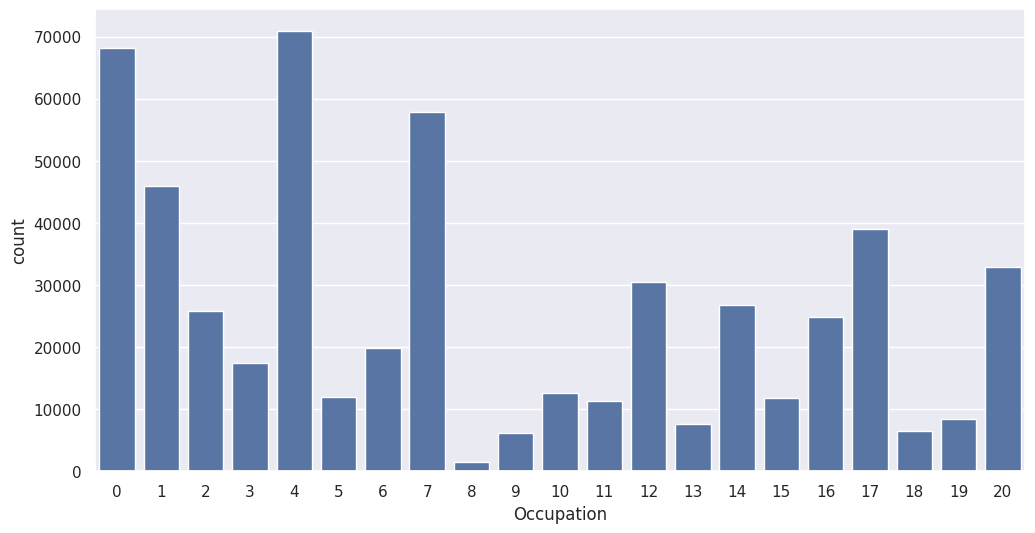

In [ ]:
sns.countplot(x='Occupation',data=df)

<Axes: xlabel='Occupation', ylabel='count'>

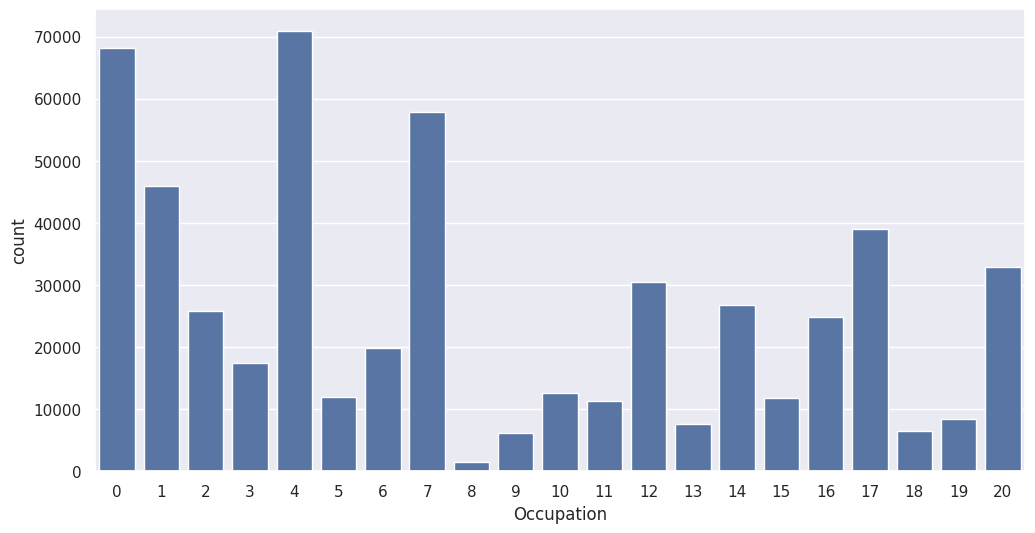

In [ ]:
sns.countplot(x=df['Occupation'])

<Axes: xlabel='Occupation'>

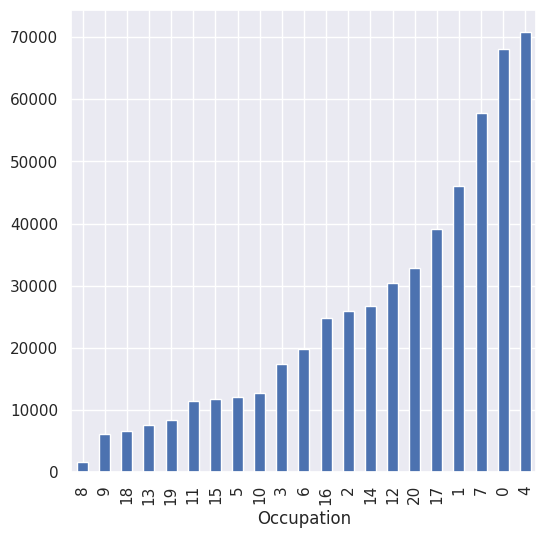

In [ ]:
df.groupby('Occupation').size().sort_values().plot(kind='bar',figsize=(6,6))

<Axes: xlabel='Occupation'>

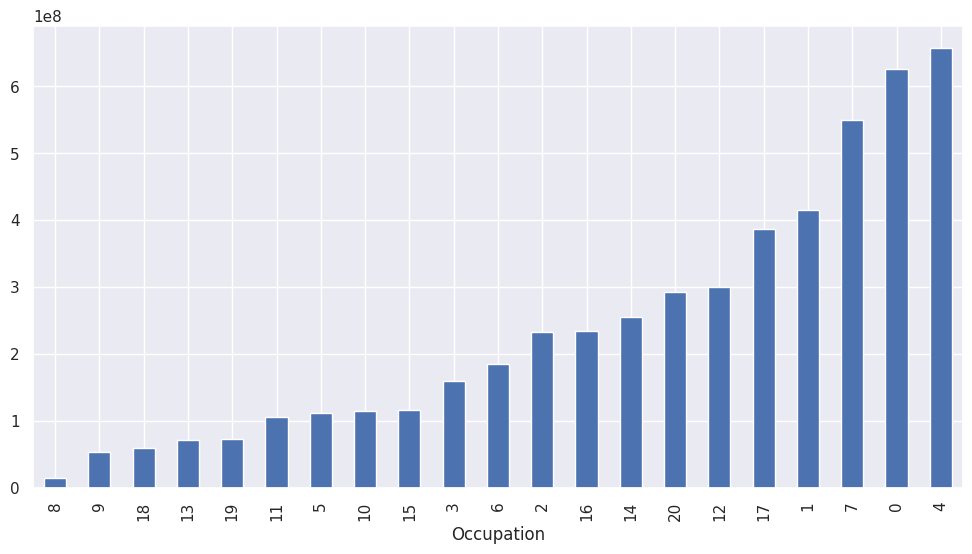

In [ ]:
df.groupby('Occupation')['Purchase'].sum().sort_values().plot(kind='bar')

<Axes: xlabel='Occupation'>

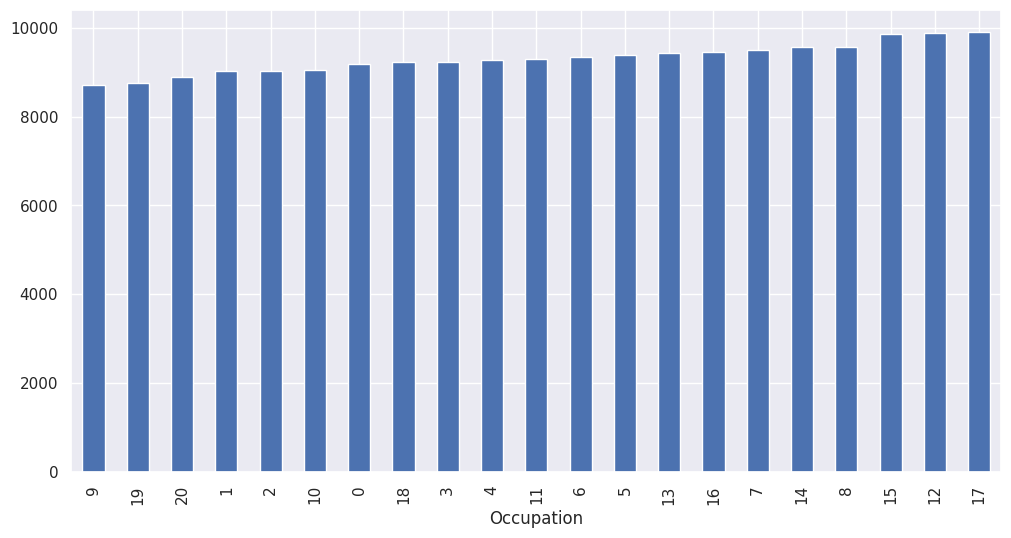

In [ ]:
df.groupby('Occupation')['Purchase'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='Occupation', ylabel='count'>

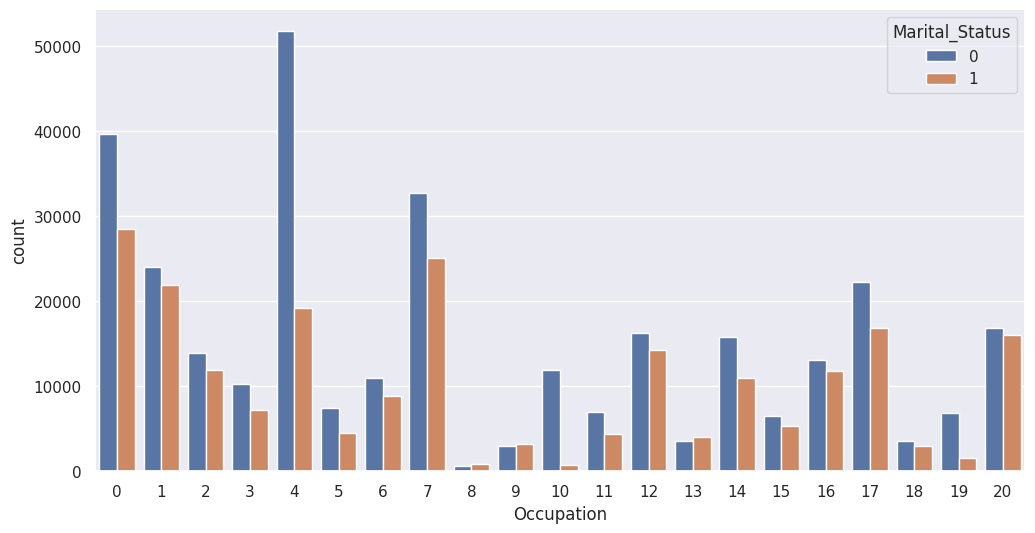

In [ ]:
sns.countplot(x='Occupation',hue='Marital_Status',data=df)

<Axes: xlabel='Occupation', ylabel='count'>

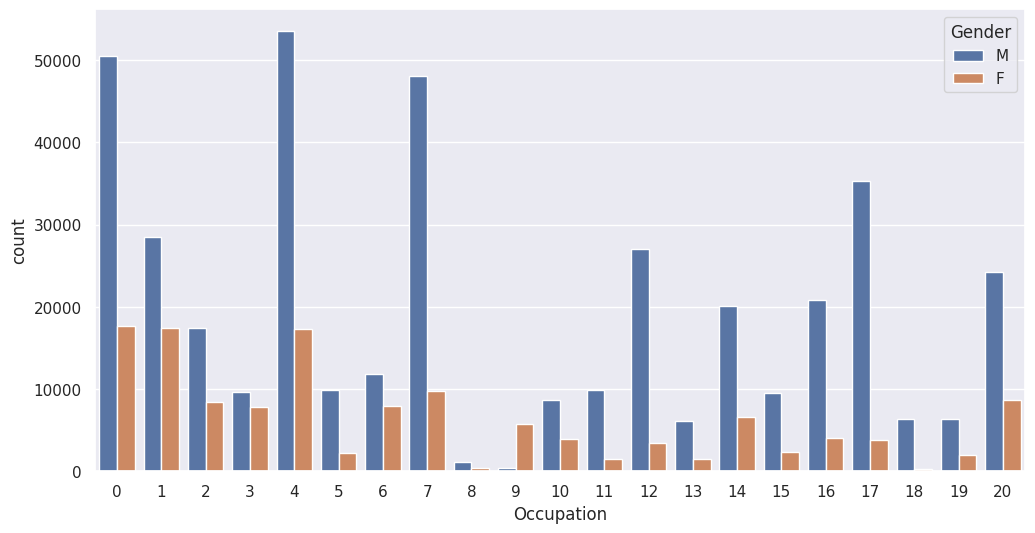

In [ ]:
sns.countplot(x='Occupation',hue='Gender',data=df)

<Axes: xlabel='Occupation'>

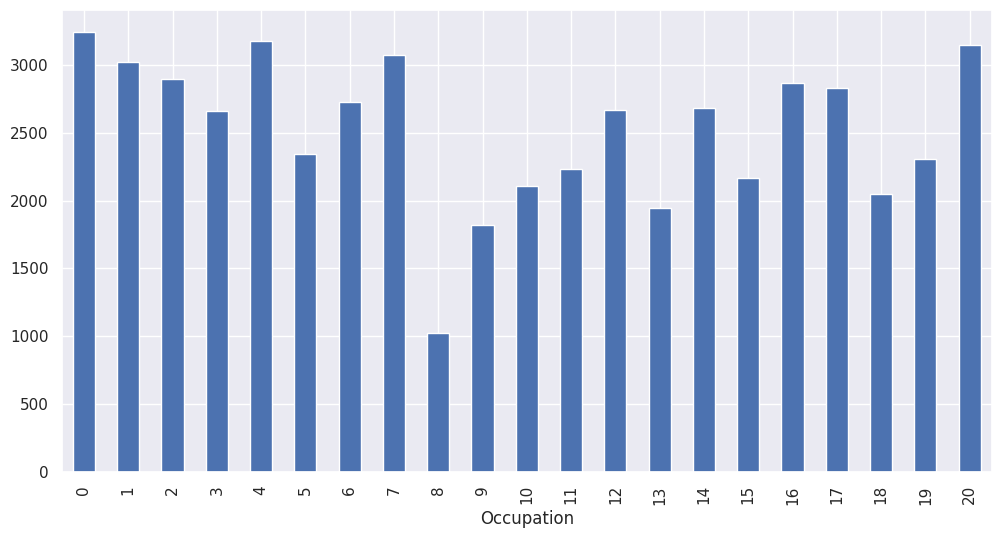

In [ ]:
df.groupby('Occupation')['Product_ID'].nunique().plot(kind='bar')

<Axes: xlabel='Occupation'>

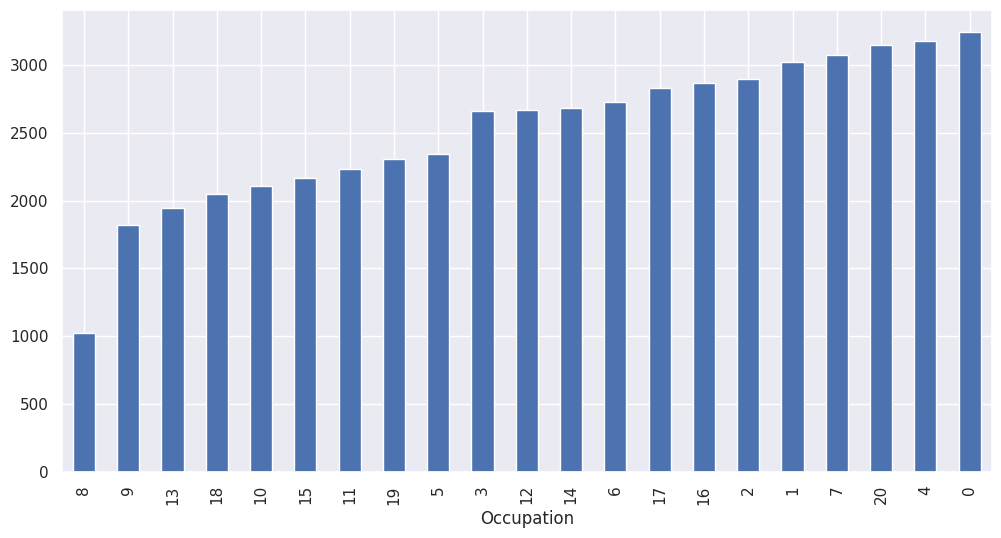

In [ ]:
df.groupby('Occupation')['Product_ID'].nunique().sort_values().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

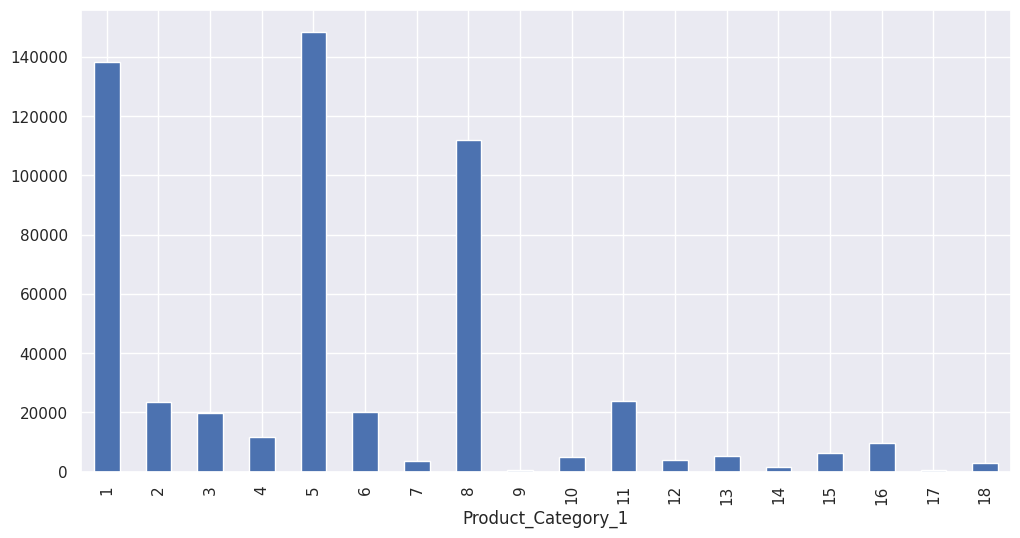

In [ ]:
df.groupby('Product_Category_1').size().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

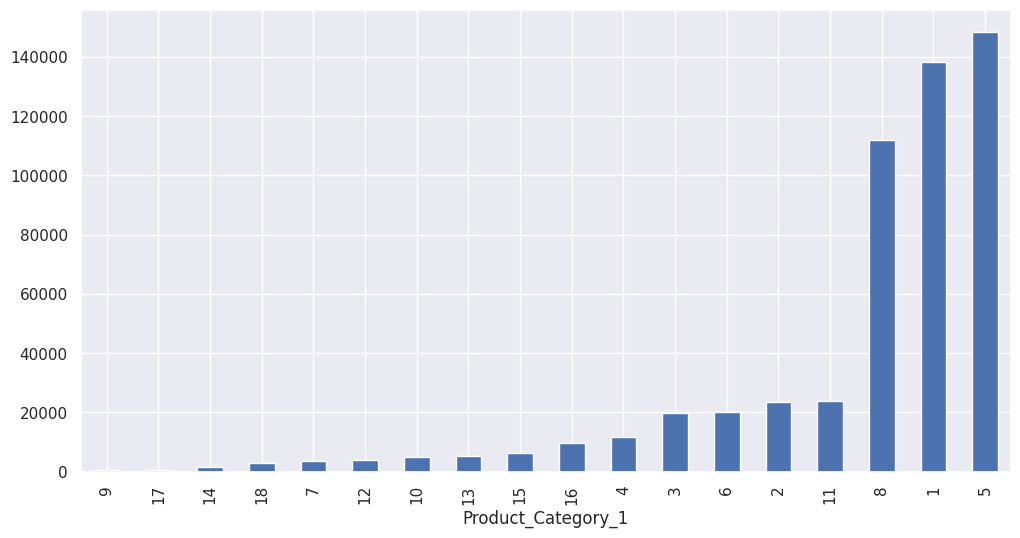

In [ ]:
df.groupby('Product_Category_1').size().sort_values().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

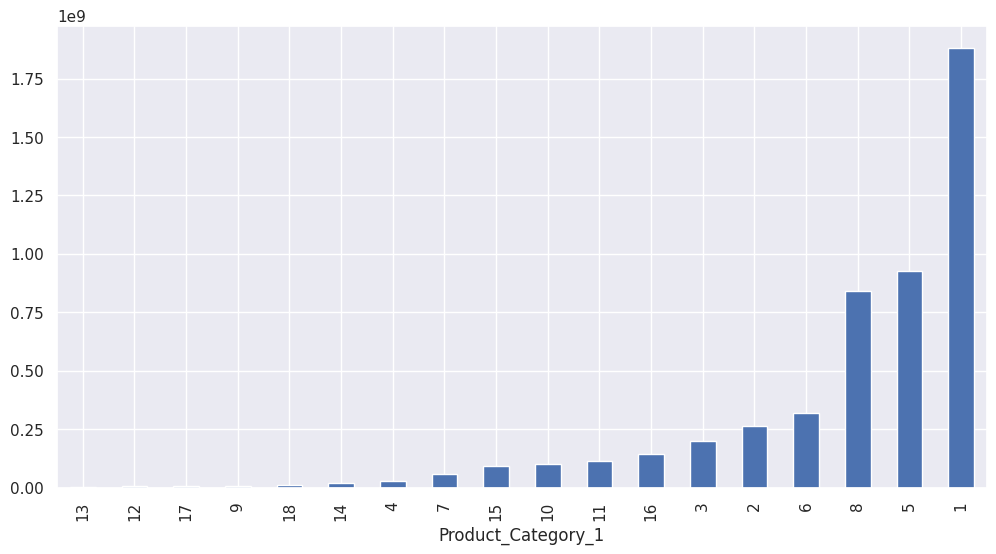

In [ ]:
df.groupby('Product_Category_1')['Purchase'].sum().sort_values().plot(kind='bar')

<Axes: xlabel='Product_Category_1'>

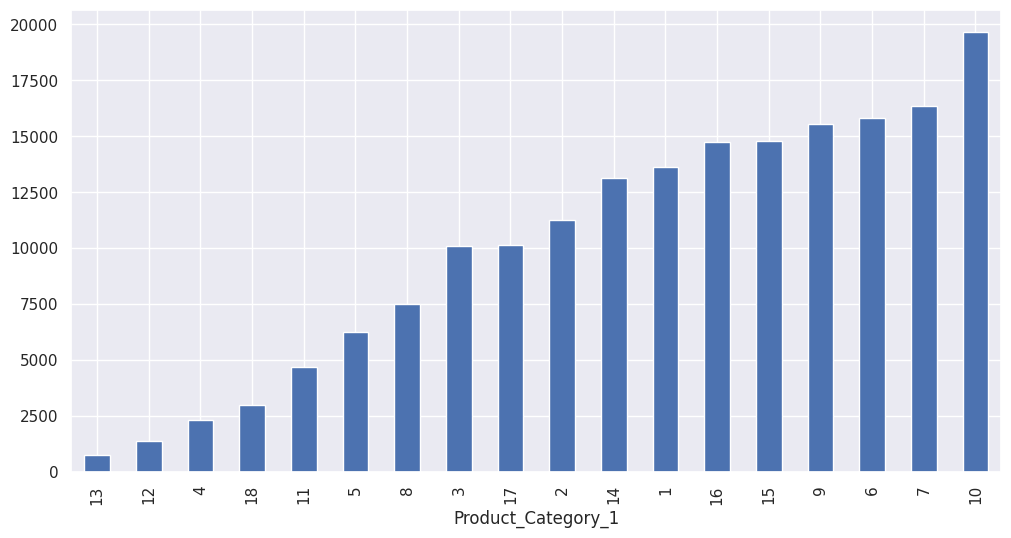

In [ ]:
df.groupby('Product_Category_1')['Purchase'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='Product_ID'>

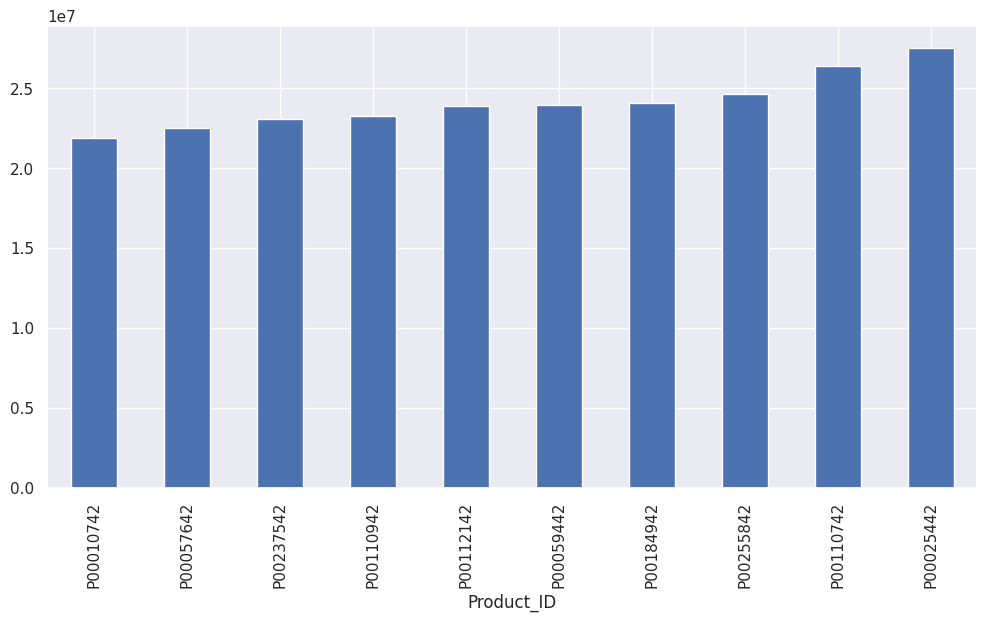

In [ ]:
df.groupby('Product_ID').sum()['Purchase'].nlargest(10).sort_values().plot(kind='bar')

<Axes: xlabel='Product_ID'>

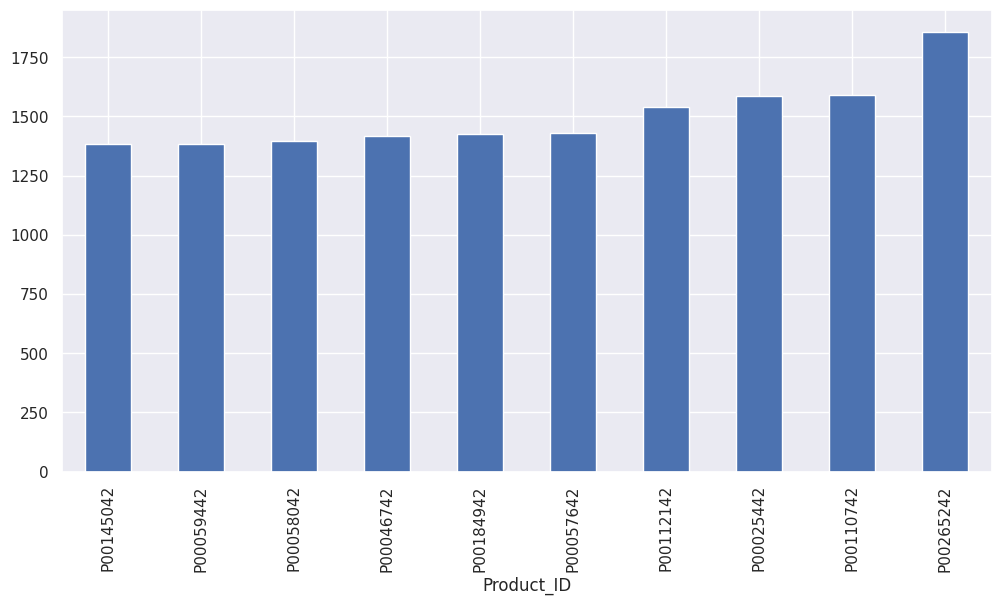

In [ ]:
df.groupby('Product_ID').size().nlargest(10).sort_values().plot(kind='bar')

<Axes: xlabel='Product_ID'>

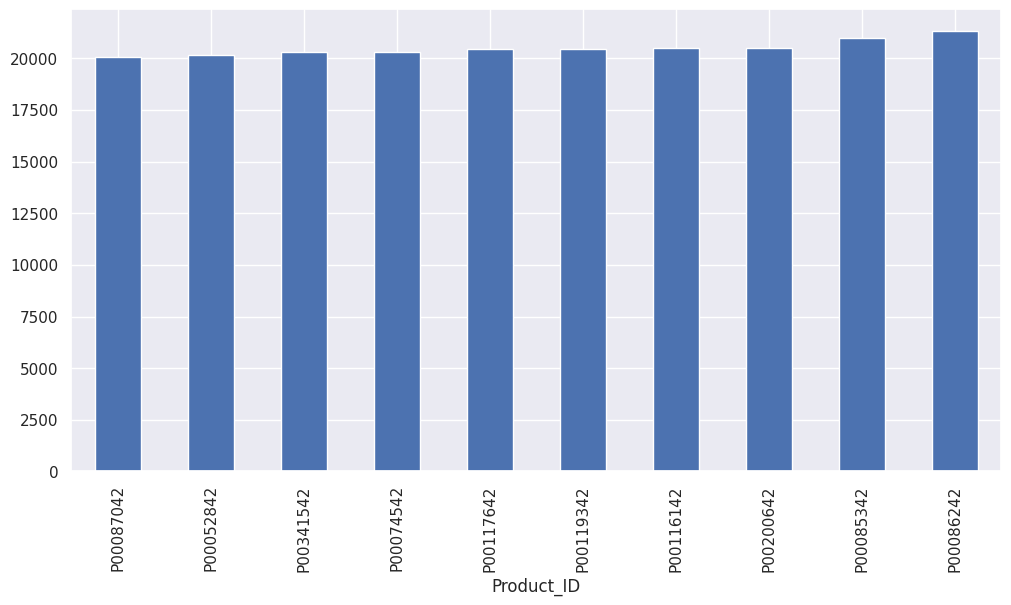

In [ ]:
df.groupby('Product_ID')['Purchase'].mean().nlargest(10).sort_values().plot(kind='bar')

<Axes: xlabel='Product_Category_1', ylabel='count'>

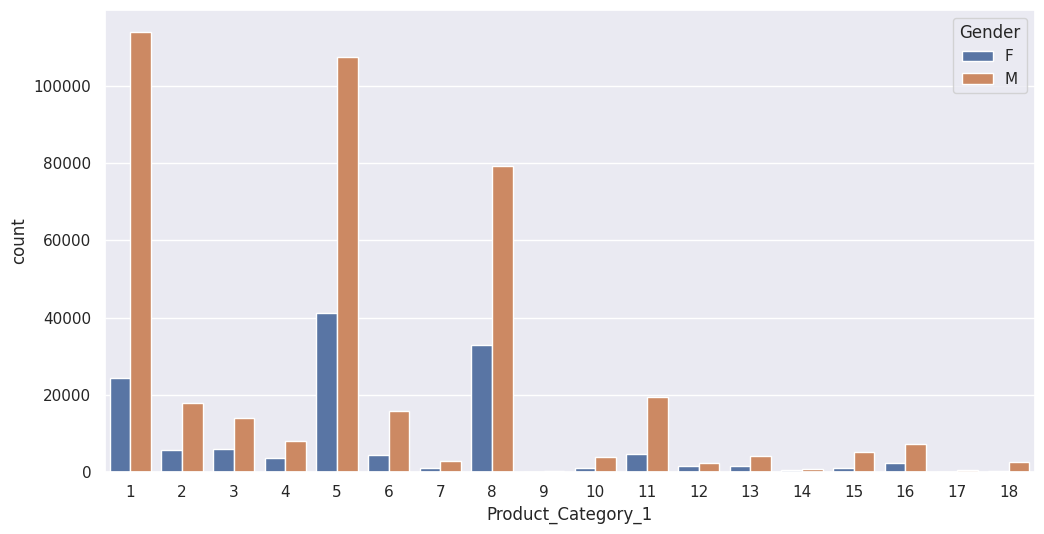

In [ ]:
sns.countplot(x='Product_Category_1',hue='Gender',data=df)

<Axes: xlabel='Product_Category_1', ylabel='count'>

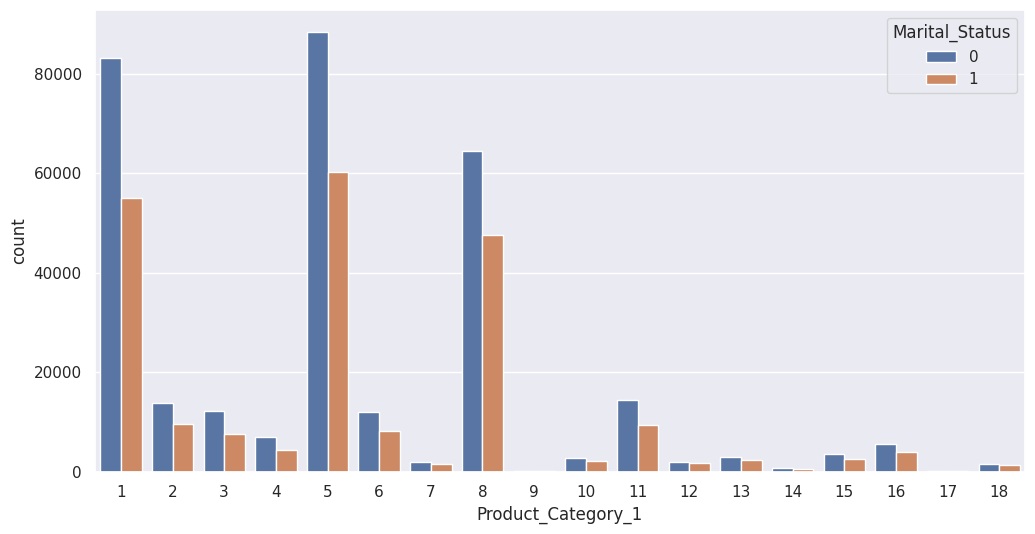

In [ ]:
sns.countplot(x='Product_Category_1',hue='Marital_Status',data=df)

In [ ]:
l = []

for i in range(len(df)):
    value = str(df['Gender'][i]) + "_" + str(df['Marital_Status'][i])
    l.append(value)

df['MaritalGender'] = l


In [ ]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase,MaritalGender
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,F_0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,F_0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,F_0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,F_0
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,M_0


<Axes: xlabel='MaritalGender', ylabel='count'>

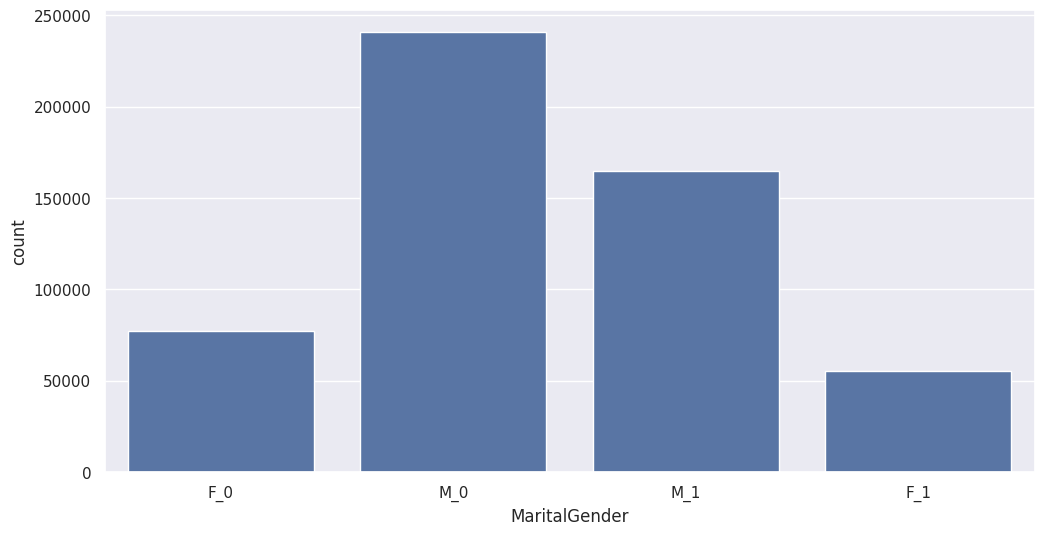

In [ ]:
sns.countplot(x=df['MaritalGender'])

<Axes: xlabel='Age', ylabel='count'>

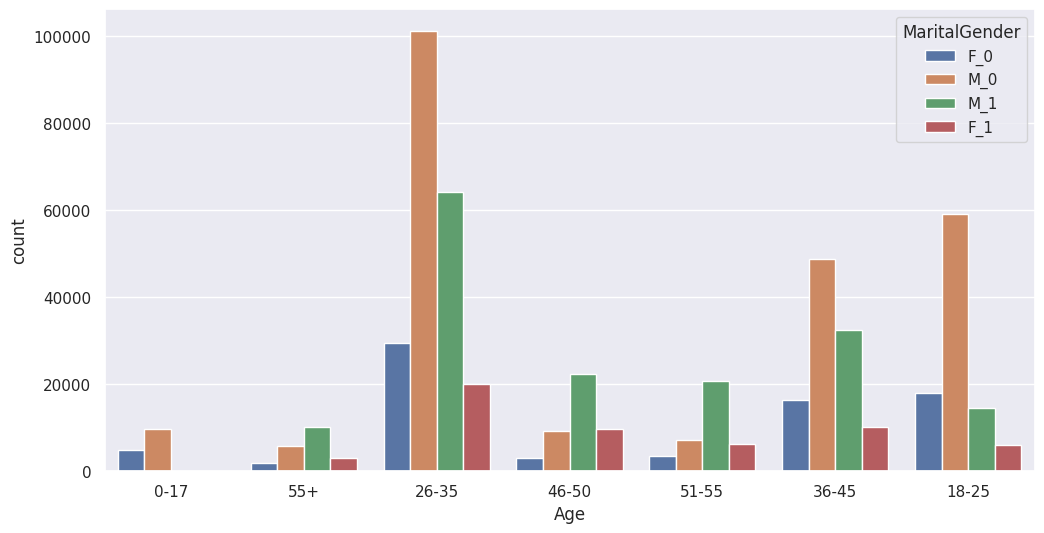

In [ ]:
sns.countplot(x='Age',hue='MaritalGender',data=df)

<Axes: xlabel='Product_Category_1', ylabel='count'>

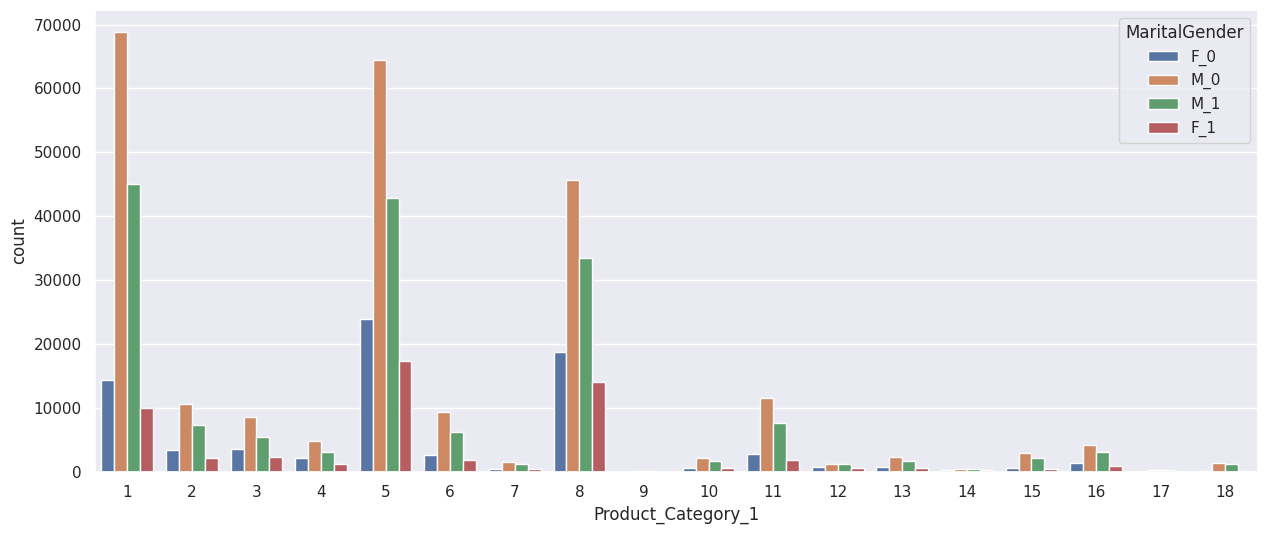

In [ ]:
sns.set(rc={'figure.figsize':(15,6)})
sns.countplot(x='Product_Category_1',hue='MaritalGender',data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

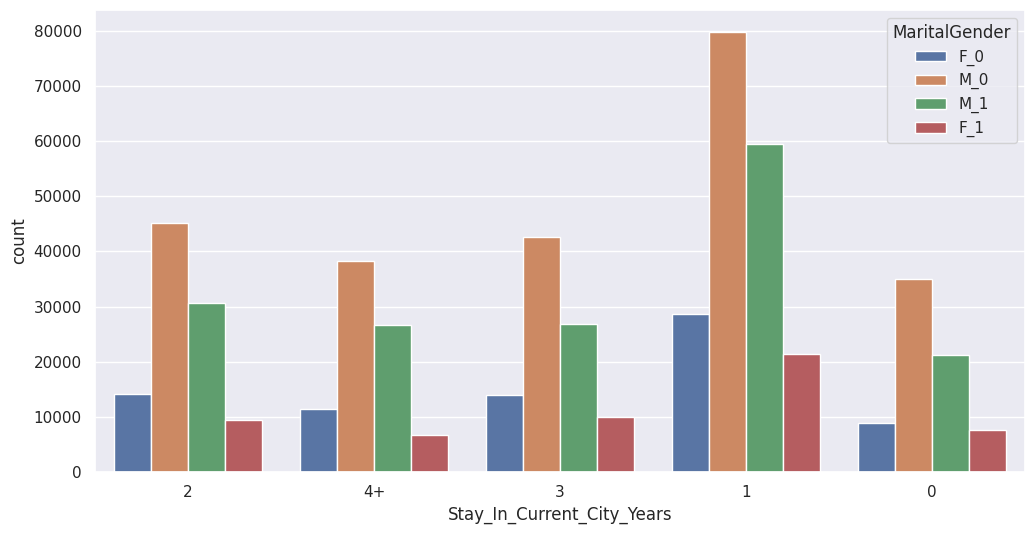

In [ ]:
sns.set(rc={'figure.figsize':(12,6)})
sns.countplot(x='Stay_In_Current_City_Years',hue='MaritalGender',data=df)

<Axes: xlabel='City_Category', ylabel='count'>

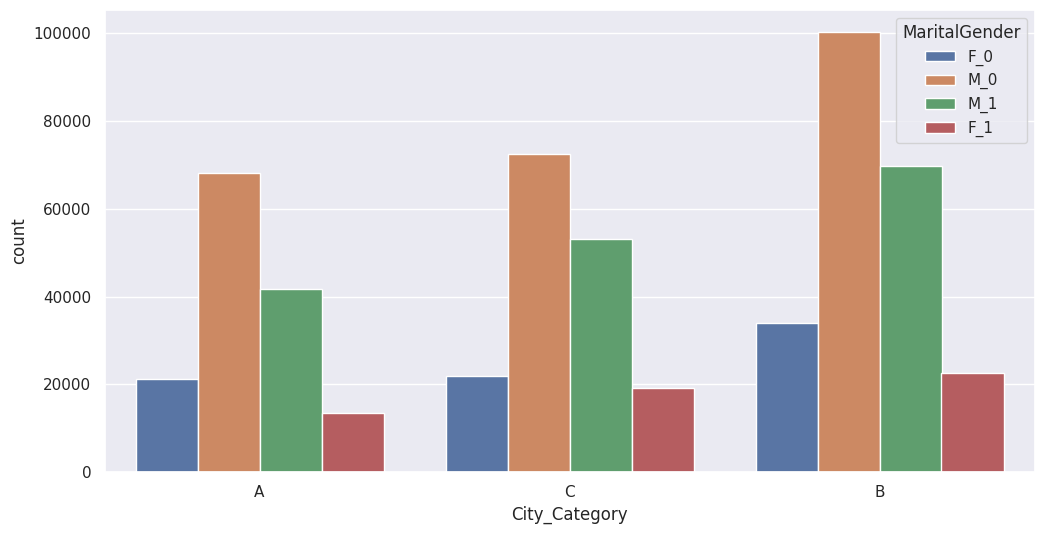

In [ ]:
sns.countplot(x='City_Category',hue='MaritalGender',data=df)